# Perceptron — Binary Linear Classifier

**Course**: CMOR 438 / INDE 577 — Data Science & Machine Learning  
**Dataset**: International Football Results (1872–present)  
**Author**: Neriah29  

---

## What is a Perceptron?

The **Perceptron** is the oldest and simplest machine learning algorithm for classification. Invented by Frank Rosenblatt in 1958, it was the first algorithm that could *learn* from labeled data to classify inputs into two categories.

At its core, the Perceptron answers one question:

> *"Given a vector of numbers describing something, does it belong to class 0 or class 1?"*

### The Intuition

Imagine plotting all your data points on a graph. Each point belongs to one of two groups. The Perceptron tries to draw a **straight line** (or a flat plane, in higher dimensions) that separates the two groups. Points on one side = class 0, points on the other side = class 1.

That separating line is called the **decision boundary**. The Perceptron's job during training is to find the right position and tilt for that line.

### The Mechanics (high-level)

1. **Each input feature gets a weight** — a number saying how important it is. There's also a **bias** term (think of it as the y-intercept of the line).
2. **Compute a weighted sum**: $z = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b$
3. **Apply the step function**: if $z \geq 0$, predict class 1. If $z < 0$, predict class 0.
4. **Update rule**: if the prediction is wrong, nudge the weights in the direction that would have gotten it right.

Repeat for every training sample, many times over. That's it.

### Key Limitation

The Perceptron only works if the data is **linearly separable** — i.e., a straight line *can* separate the two classes. If the classes are interleaved or form complex shapes, the Perceptron will never converge. This is why it's considered a **historical stepping stone**, not a production classifier. Real-world data (including football!) is almost never linearly separable.

---

## Why Study It at All?

The Perceptron is the **building block of neural networks**. A multi-layer neural network is just many Perceptron-like units stacked together with different activation functions. Understanding the Perceptron gives you the conceptual foundation for everything that follows in this course.


---
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Our custom implementation
import sys
sys.path.insert(0, '../../src')
from football_ml.supervised_learning.perceptron import Perceptron

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42

---
## 1. Load & Explore the Dataset

In [2]:
df = pd.read_csv('../../data/results.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [4]:
df.describe()

,home_score,away_score
count,49215.000000,49215.000000
mean,1.756091,1.182404
std,1.770617,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


---
## 2. Feature Engineering

The raw dataset has columns: `home_team`, `away_team`, `home_score`, `away_score`, `tournament`, `city`, `country`, `neutral` (bool).

We can't feed raw text into a Perceptron — we need **numerical features**.

### Target variable

Since the Perceptron is a **binary** classifier, we'll predict:
- **1** → Home team wins
- **0** → Draw or Away win

### Features we'll engineer

| Feature | Description |
|---|---|
| `home_goals_rolling` | Home team's average goals scored in last 10 games |
| `away_goals_rolling` | Away team's average goals scored in last 10 games |
| `home_conceded_rolling` | Home team's average goals conceded in last 10 games |
| `away_conceded_rolling` | Away team's average goals conceded in last 10 games |
| `home_win_rate` | Home team's overall historical win rate |
| `away_win_rate` | Away team's overall historical win rate |
| `neutral` | Whether the match is on neutral ground (0/1) |

> **Why rolling averages?** A team's recent form matters more than their all-time record. Rolling 10-game windows give us a sense of current momentum.

In [5]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Binary target: 1 = home win, 0 = draw or away win
df['home_win'] = (df['home_score'] > df['away_score']).astype(int)

# Helper: compute rolling stats for each team appearing as home or away
def compute_team_rolling_stats(df, window=10):
    """
    For each match, compute the rolling average goals scored/conceded
    for both the home and away team over their last `window` matches
    (regardless of home/away role in those past matches).
    """
    # Build a per-team match log
    home_log = df[['date', 'home_team', 'home_score', 'away_score']].copy()
    home_log.columns = ['date', 'team', 'scored', 'conceded']

    away_log = df[['date', 'away_team', 'away_score', 'home_score']].copy()
    away_log.columns = ['date', 'team', 'scored', 'conceded']

    team_log = pd.concat([home_log, away_log]).sort_values('date').reset_index(drop=True)

    # Rolling averages (shift(1) to avoid leakage — use only *past* games)
    team_log['rolling_scored'] = (
        team_log.groupby('team')['scored']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    team_log['rolling_conceded'] = (
        team_log.groupby('team')['conceded']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

    # Deduplicate: keep most recent entry per (date, team)
    team_stats = team_log.drop_duplicates(subset=['date', 'team'], keep='last')
    team_stats = team_stats.set_index(['date', 'team'])
    return team_stats

team_stats = compute_team_rolling_stats(df)
print('Team stats sample:')
team_stats.head(10)

Team stats sample:


scored  conceded  rolling_scored  rolling_conceded
date       team                                                        
1872-11-30 Scotland     0.0       0.0             NaN               NaN
           England      0.0       0.0             NaN               NaN
1873-03-08 Scotland     2.0       4.0        0.000000          0.000000
           England      4.0       2.0        0.000000          0.000000
1874-03-07 England      1.0       2.0        2.000000          1.000000
           Scotland     2.0       1.0        1.000000          2.000000
1875-03-06 Scotland     2.0       2.0        1.333333          1.666667
           England      2.0       2.0        1.666667          1.333333
1876-03-04 England      0.0       3.0        1.750000          1.500000
           Scotland     3.0       0.0        1.500000          1.750000

In [6]:
# Join rolling stats back onto the main dataframe
def get_stat(row, team_col, stat_col, team_stats):
    try:
        return team_stats.loc[(row['date'], row[team_col]), stat_col]
    except KeyError:
        return np.nan

df['home_goals_rolling'] = df.apply(lambda r: get_stat(r, 'home_team', 'rolling_scored', team_stats), axis=1)
df['home_conceded_rolling'] = df.apply(lambda r: get_stat(r, 'home_team', 'rolling_conceded', team_stats), axis=1)
df['away_goals_rolling'] = df.apply(lambda r: get_stat(r, 'away_team', 'rolling_scored', team_stats), axis=1)
df['away_conceded_rolling'] = df.apply(lambda r: get_stat(r, 'away_team', 'rolling_conceded', team_stats), axis=1)

# Overall win rate per team (historical, computed up front — simpler alternative)
home_wins = df.groupby('home_team')['home_win'].mean().rename('home_win_rate')
away_wins = (df.assign(away_win=(df['away_score'] > df['home_score']).astype(int))
               .groupby('away_team')['away_win'].mean().rename('away_win_rate'))

df = df.join(home_wins, on='home_team').join(away_wins, on='away_team')
df['neutral'] = df['neutral'].astype(int)

# Drop rows with missing rolling stats (early matches have no history)
feature_cols = [
    'home_goals_rolling', 'away_goals_rolling',
    'home_conceded_rolling', 'away_conceded_rolling',
    'home_win_rate', 'away_win_rate',
    'neutral'
]
df_clean = df[feature_cols + ['home_win']].dropna()
print(f'Clean dataset: {df_clean.shape[0]} rows, {len(feature_cols)} features')
df_clean.head()

Clean dataset: 48987 rows, 7 features


,home_goals_rolling,away_goals_rolling,home_conceded_rolling,away_conceded_rolling,home_win_rate,away_win_rate,neutral,home_win
1,0.000000,0.000000,0.000000,0.000000,0.618182,0.387615,0,1
2,1.000000,2.000000,2.000000,1.000000,0.555288,0.523105,0,1
3,1.666667,1.333333,1.333333,1.666667,0.618182,0.387615,0,0
4,1.500000,1.750000,1.750000,1.500000,0.555288,0.523105,0,1
6,1.400000,2.166667,1.800000,1.166667,0.618182,0.387615,0,0


### Class Balance

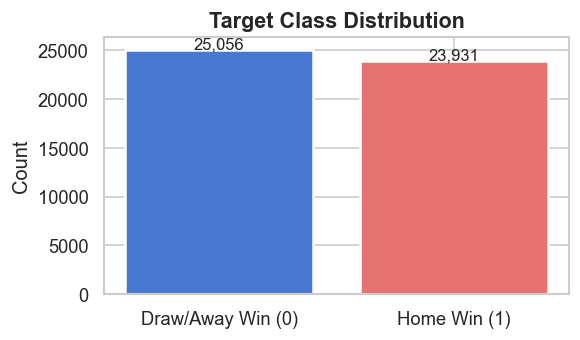

Home win rate: 48.9%


In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
counts = df_clean['home_win'].value_counts()
ax.bar(['Draw/Away Win (0)', 'Home Win (1)'], counts.values,
       color=['#4878CF', '#E87272'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=10)
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Home win rate: {counts[1] / counts.sum():.1%}")

---
## 3. Prepare Data for the Perceptron

In [8]:
X = df_clean[feature_cols].values
y = df_clean['home_win'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Feature scaling is important for the Perceptron.
# The update rule moves weights by learning_rate * x. If x is large (e.g. 100)
# while another feature is small (e.g. 0.1), training becomes unstable.
# StandardScaler makes every feature have mean=0, std=1.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print(f'Train: {X_train_sc.shape}, Test: {X_test_sc.shape}')

Train: (39189, 7), Test: (9798, 7)


---
## 4. Train the Perceptron

In [ ]:
model = Perceptron(learning_rate=0.01, n_epochs=100000, random_state=SEED)
model.fit(X_train_sc, y_train)

print(f'Converged after {len(model.errors_per_epoch_)} epochs')
print(f'Train accuracy: {model.score(X_train_sc, y_train):.3f}')
print(f'Test  accuracy: {model.score(X_test_sc,  y_test):.3f}')

---
## 5. Visualization — Learning Curve

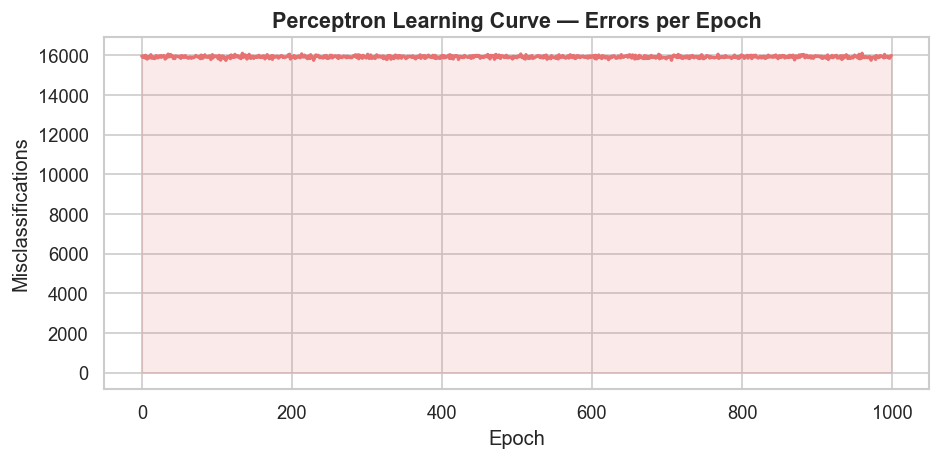

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.errors_per_epoch_, color='#E87272', linewidth=2)
ax.fill_between(range(len(model.errors_per_epoch_)),
                model.errors_per_epoch_, alpha=0.15, color='#E87272')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Misclassifications', fontsize=12)
ax.set_title('Perceptron Learning Curve — Errors per Epoch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### What does this curve tell us?

- If the error **reaches 0**, the Perceptron found a perfect linear separator — the data was linearly separable.
- If the error **bounces around** and never settles, the data is **not linearly separable**. The Perceptron will oscillate forever (that's why we cap at `n_epochs`).
- Real football data is almost certainly not linearly separable — too many overlapping situations, too much randomness.

---
## 6. Evaluate — Confusion Matrix & Classification Report

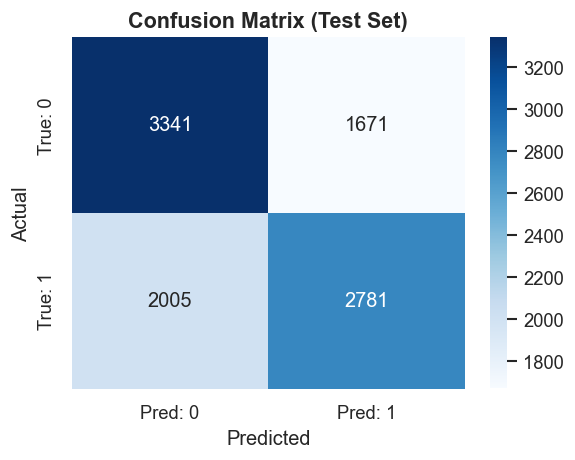

              precision    recall  f1-score   support

   Draw/Away       0.62      0.67      0.65      5012
    Home Win       0.62      0.58      0.60      4786

    accuracy                           0.62      9798
   macro avg       0.62      0.62      0.62      9798
weighted avg       0.62      0.62      0.62      9798



In [11]:
y_pred = model.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['True: 0', 'True: 1'], ax=ax)
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Draw/Away', 'Home Win']))

### Reading the Confusion Matrix

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | True Negatives (TN) | False Positives (FP) |
| **Actual 1** | False Negatives (FN) | True Positives (TP) |

- **Precision**: Of all matches predicted as Home Win, what fraction actually were?  
- **Recall**: Of all actual Home Wins, what fraction did we correctly identify?
- **F1-score**: Harmonic mean of precision and recall — a balanced single metric.

---
## 7. Feature Weights Visualization

After training, the weights tell us how much each feature influences the decision.

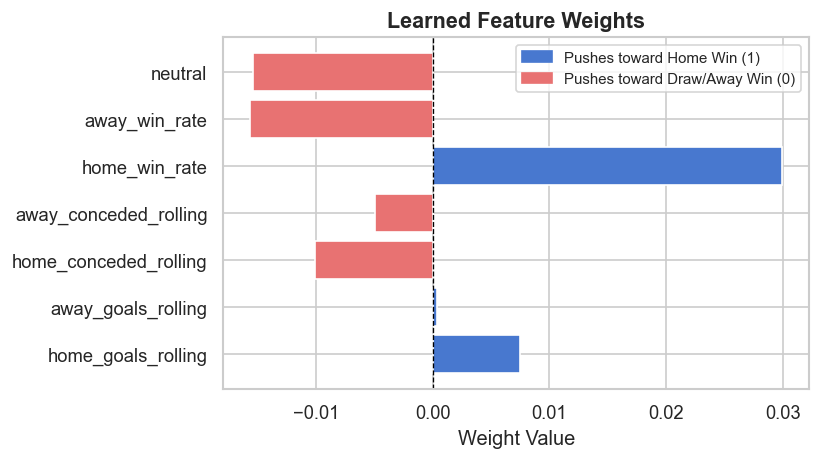

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4878CF' if w > 0 else '#E87272' for w in model.weights_]
bars = ax.barh(feature_cols, model.weights_, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Weight Value', fontsize=12)
ax.set_title('Learned Feature Weights', fontsize=13, fontweight='bold')

pos_patch = mpatches.Patch(color='#4878CF', label='Pushes toward Home Win (1)')
neg_patch = mpatches.Patch(color='#E87272', label='Pushes toward Draw/Away Win (0)')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. 2D Decision Boundary (on 2 features)

To *visualize* the decision boundary, we train a fresh model on just **two features** so we can plot it in 2D.

/var/folders/5x/_pfc6v411ms6kdxklz7tft_w0000gn/T/ipykernel_28911/826218881.py:31: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(*scatter.legend_elements(), labels=['Draw/Away Win', 'Home Win'])


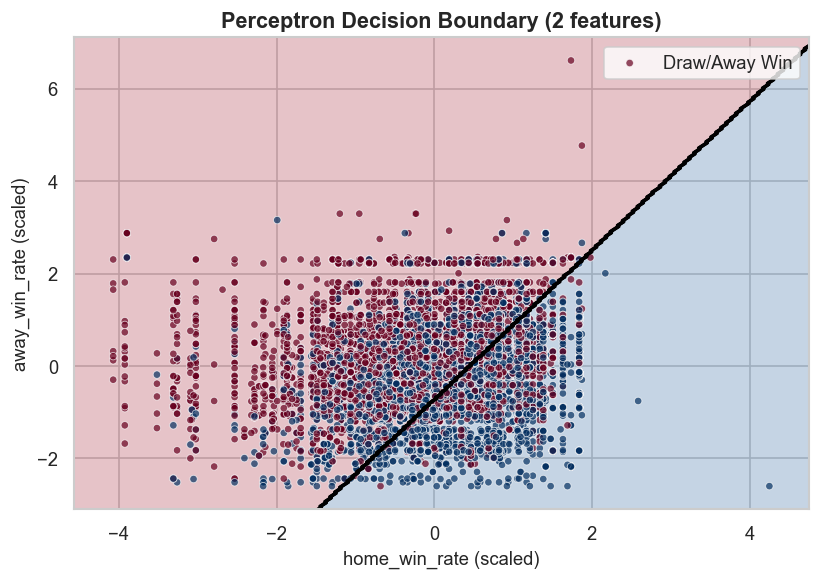

2D model test accuracy: 0.639


In [13]:
# Train on home_win_rate vs away_win_rate only
feat_idx = [4, 5]  # indices of home_win_rate, away_win_rate
X2 = X[:, feat_idx]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=SEED, stratify=y
)
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

model2d = Perceptron(learning_rate=0.01, n_epochs=500, random_state=SEED)
model2d.fit(X2_train_sc, y2_train)

# --- Plot ---
xx, yy = np.meshgrid(
    np.linspace(X2_train_sc[:, 0].min() - 0.5, X2_train_sc[:, 0].max() + 0.5, 300),
    np.linspace(X2_train_sc[:, 1].min() - 0.5, X2_train_sc[:, 1].max() + 0.5, 300),
)
Z = model2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
ax.contour(xx, yy, Z, colors='black', linewidths=1.5)
scatter = ax.scatter(
    X2_test_sc[:, 0], X2_test_sc[:, 1],
    c=y2_test, cmap='RdBu', edgecolors='white', linewidth=0.5, s=20, alpha=0.7
)
ax.set_xlabel('home_win_rate (scaled)', fontsize=11)
ax.set_ylabel('away_win_rate (scaled)', fontsize=11)
ax.set_title('Perceptron Decision Boundary (2 features)', fontsize=13, fontweight='bold')
legend = ax.legend(*scatter.legend_elements(), labels=['Draw/Away Win', 'Home Win'])
plt.tight_layout()
plt.show()

print(f'2D model test accuracy: {model2d.score(X2_test_sc, y2_test):.3f}')

The straight black line **is** the Perceptron's decision boundary — a single hyperplane slicing through the feature space. Notice how many points are on the 'wrong' side: the two classes are not cleanly separable.

---
## 9. Discussion — Does the Perceptron Suit Football Prediction?

### What went well
- Simple to implement and interpret.
- Feature weights give a rough sense of which factors matter.
- Fast to train even on tens of thousands of samples.

### What didn't work well

1. **Football is not linearly separable.** A high home win rate doesn't guarantee a win. A weak team can beat a strong one. These overlapping situations are everywhere — no straight line can cleanly separate wins from non-wins.

2. **The step function throws away information.** The Perceptron outputs a hard 0 or 1 — no sense of *confidence*. A match the model barely predicted as a home win looks identical to a certain home win.

3. **Binary only.** We collapsed Draw and Away Win into one class. This loses important information. (Football has three outcomes; we artificially made it two.)

4. **No feature interactions.** The Perceptron can only learn linear combinations. It can't capture "home team scores a lot *and* away team has a weak defense" as a compound signal.

### What comes next

| Limitation | How later algorithms address it |
|---|---|
| Not linearly separable | Logistic Regression, Neural Networks, SVM |
| No confidence scores | Logistic Regression (outputs probabilities) |
| Multi-class | Logistic Regression (softmax), Neural Nets |
| Feature interactions | Neural Networks, Decision Trees, Ensembles |

The Perceptron is a conceptual foundation, not a practical tool for football. But every neural network you'll study this semester is built on exactly this idea.

---
## Summary

| | |
|---|---|
| **Algorithm type** | Binary linear classifier |
| **Decision boundary** | Hyperplane (linear) |
| **Activation** | Step function (hard 0/1) |
| **Update rule** | Adjust weights on each misclassification |
| **Convergence guarantee** | Only if data is linearly separable |
| **Football suitability** | Low — data is not linearly separable |
| **Historical significance** | Foundation of neural networks |
